## Name : Rajkumar Rajak
## Scholar No : 25215011118
## LAB 6 (PART 2) : Variational autoencoder


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-images-idx3-ubyte


Device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.4MB/s]


Training images loaded: 60000
Training started...


Epoch 1: 100%|██████████| 469/469 [00:10<00:00, 44.84it/s, loss=272]


Epoch 1 Average Loss: 289.6391


...

Epoch 8 Average Loss: 244.8832


Epoch 9: 100%|██████████| 469/469 [00:08<00:00, 52.23it/s, loss=255]


Epoch 9 Average Loss: 244.3377


Epoch 10: 100%|██████████| 469/469 [00:09<00:00, 51.66it/s, loss=230]


Epoch 10 Average Loss: 243.9001


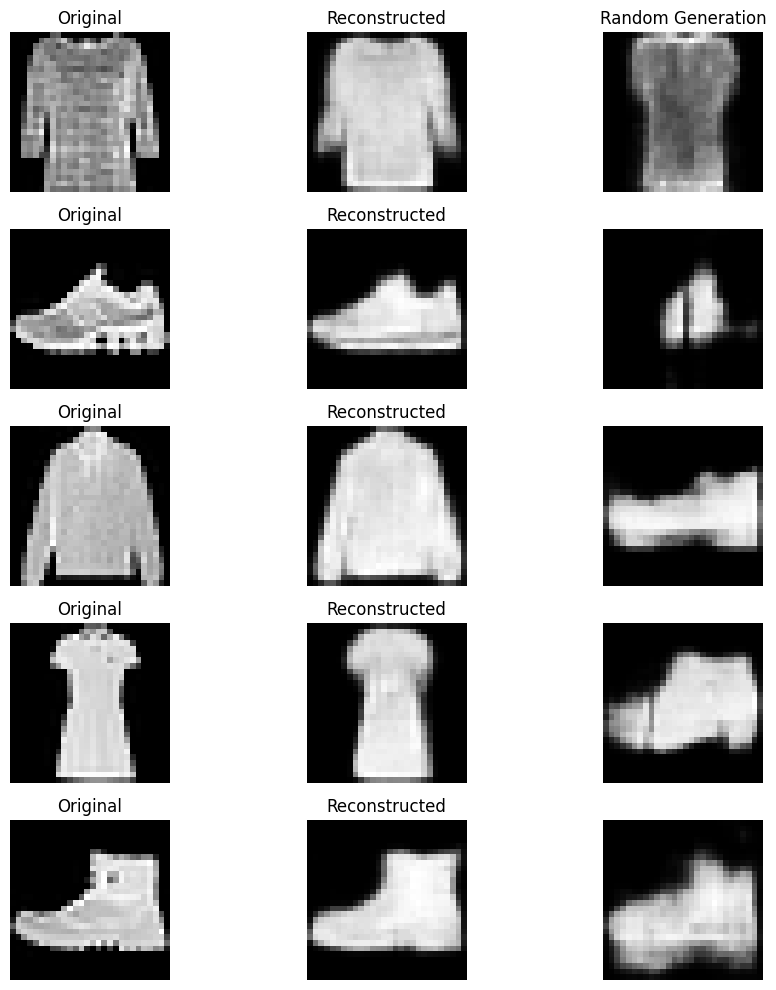

In [ ]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 10
LATENT_DIM = 64 # Dimensionality of the latent space
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform)

test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)

print("Training images loaded:", len(train_dataset))


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(VAE, self).__init__()

        #  ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 14 -> 7
            nn.ReLU()
        )


        self.flatten_size = 64 * 7 * 7
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

        #  DECODER
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),  # 14 -> 28
            nn.Sigmoid() # Output bounded between 0 and 1
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1) # Flatten
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Reparameterization trick: z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 64, 7, 7) # Unflatten back to spatial tensor
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed_x = self.decode(z)
        return reconstructed_x, mu, logvar


def vae_loss(recon_x, x, mu, logvar):

    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    #  Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

model = VAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training started...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    loop = tqdm(train_loader)
    for images, _ in loop:
        images = images.to(DEVICE)

        # Forward pass
        reconstructed, mu, logvar = model(images)

        # Calculate VAE Loss
        loss = vae_loss(reconstructed, images, mu, logvar)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")
        # Divide by batch size for readable console output
        loop.set_postfix(loss=loss.item() / len(images))

    print(f"Epoch {epoch+1} Average Loss: {running_loss/len(train_dataset):.4f}")


model.eval()

# Get a test batch
images, _ = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    # 1. Reconstruction Test
    reconstructed, _, _ = model(images)

    # 2. Generative Test (Sampling random noise from latent space)
    random_latent_vectors = torch.randn(5, LATENT_DIM).to(DEVICE)
    generated_images = model.decode(random_latent_vectors)

images = images.cpu().numpy()
reconstructed = reconstructed.cpu().numpy()
generated_images = generated_images.cpu().numpy()

plt.figure(figsize=(10, 10))

for i in range(5):
    # Original
    plt.subplot(5, 3, 3*i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(5, 3, 3*i + 2)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

    # Generated (From random noise)
    plt.subplot(5, 3, 3*i + 3)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    if i == 0:
        plt.title("Random Generation")
    plt.axis('off')

plt.tight_layout()
plt.show()